In [1]:
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt

## Point 1: Gaia DR3 × 2MASS crossmatch around M67

ADQL query joining `gaiadr3.gaia_source` with 2MASS via the pre-computed
crossmatch tables (`gaiadr3.tmass_psc_xsc_best_neighbour` and
`gaiadr3.tmass_psc_xsc_join`), linking to `gaiadr1.tmass_original_valid`
on `designation`. Selected all stars within 1° of M67
(RA=132.825°, Dec=11.8°) with G < 14.

**Result: 1018 stars returned.**

In [3]:
query = """
SELECT gaia.source_id, gaia.ra, gaia.dec, gaia.parallax, gaia.phot_g_mean_mag, gaia.bp_rp,
       tmass.designation, tmass.j_m, tmass.h_m, tmass.ks_m, tmass.ph_qual
FROM gaiadr3.gaia_source AS gaia
JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
  USING (source_id)
JOIN gaiadr3.tmass_psc_xsc_join AS xjoin
  USING (clean_tmass_psc_xsc_oid)
JOIN gaiadr1.tmass_original_valid AS tmass
  ON xjoin.original_psc_source_id = tmass.designation
WHERE 1=CONTAINS(
    POINT('ICRS', gaia.ra, gaia.dec),
    CIRCLE('ICRS', 132.825, 11.8, 1.0)
  )
  AND gaia.phot_g_mean_mag < 14
"""

job = Gaia.launch_job_async(query)
results = job.get_results()
print(f"Number of stars returned: {len(results)}")

INFO: Query finished. [astroquery.utils.tap.core]
Number of stars returned: 1018


## Point 2: Quality cuts

- Stars with bad 2MASS photometry (ph_qual != 'AAA'): 21
- Stars with non-positive parallax: 2
- Stars remaining after applying both cuts: 988

In [4]:
# Identify stars with bad 2MASS photometry
bad_photometry = results['ph_qual'] != 'AAA'
print(f"Stars with bad 2MASS photometry (ph_qual != 'AAA'): {bad_photometry.sum()}")

# Identify stars with non-positive Gaia parallax
bad_parallax = results['parallax'] <= 0
print(f"Stars with non-positive parallax: {bad_parallax.sum()}")

# Apply both quality cuts and report how many remain
mask = (results['ph_qual'] == 'AAA') & (results['parallax'] > 0)
clean_results = results[mask]
print(f"Number of stars remaining after quality cuts: {len(clean_results)}")

Stars with bad 2MASS photometry (ph_qual != 'AAA'): 21
Stars with non-positive parallax: 2
Number of stars remaining after quality cuts: 988


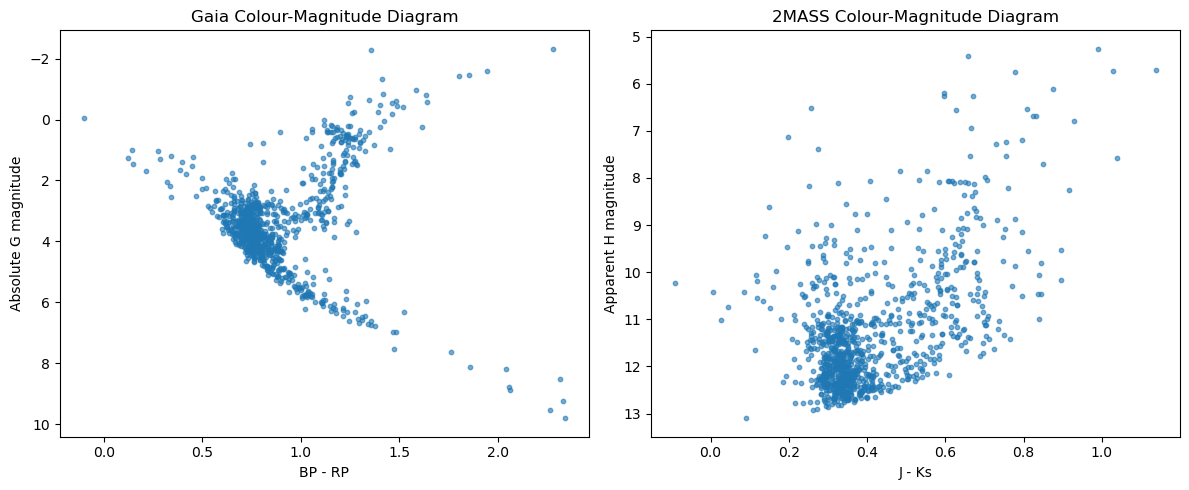

In [5]:
import numpy as np

# Use the quality-cut sample
d_pc = 1000 / clean_results['parallax']  # distance in pc (parallax in mas -> arcsec conversion folded in)
abs_G = clean_results['phot_g_mean_mag'] - 5 * np.log10(d_pc) + 5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Gaia CMD
axes[0].scatter(clean_results['bp_rp'], abs_G, s=10, alpha=0.6)
axes[0].invert_yaxis()  # brighter stars (lower mag) at top
axes[0].set_xlabel('BP - RP')
axes[0].set_ylabel('Absolute G magnitude')
axes[0].set_title('Gaia Colour-Magnitude Diagram')

# Panel 2: 2MASS CMD
j_ks = clean_results['j_m'] - clean_results['ks_m']
axes[1].scatter(j_ks, clean_results['h_m'], s=10, alpha=0.6)
axes[1].invert_yaxis()
axes[1].set_xlabel('J - Ks')
axes[1].set_ylabel('Apparent H magnitude')
axes[1].set_title('2MASS Colour-Magnitude Diagram')

plt.tight_layout()
plt.savefig('figures/m67_cmd_panels.png', dpi=150)
plt.show()

In [6]:
n_fibres_available = 392 - 25  # total science fibres minus recommended sky fibres
n_candidates = len(clean_results)

print(f"Usable science fibres (2dF/HERMES): ~{n_fibres_available}")
print(f"Quality-cut candidate stars in field: {n_candidates}")
print(f"Ratio (candidates per fibre): {n_candidates / n_fibres_available:.2f}")

Usable science fibres (2dF/HERMES): ~367
Quality-cut candidate stars in field: 988
Ratio (candidates per fibre): 2.69


## Point 4: Fibre usage recommendation 

According to GALAH Survey publications and Wittenmyer et al. (2016), the 2dF/HERMES system contains 392 science fibers per plate over a 2° field. About 25 of those fibers are usually set aside for the sky background, leaving about 367 fibers accessible for research objectives. The field of view of 2dF is precisely matched by our search area (1° radius = 2° diameter).

In this field, we discovered 988 quality-cut candidate stars (G < 14, good 2MASS photometry, positive parallax), or 2.69 candidates per available fiber.

Yes, this field is a strong fit for a 2dF/HERMES proposal based only on fiber utilization. Instead of being fiber-limited or leaving fibers unused, the observer has more than enough stars to completely fill the plate with around 2.7 times as many targets as fibers while still being selective (e.g., giving preference to brighter targets or likely cluster members over field stars).